# Chua's Circuit: part 3
We will try using a better dataset with more data points, as the electric circuit is easily measurable

In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

# Dataset

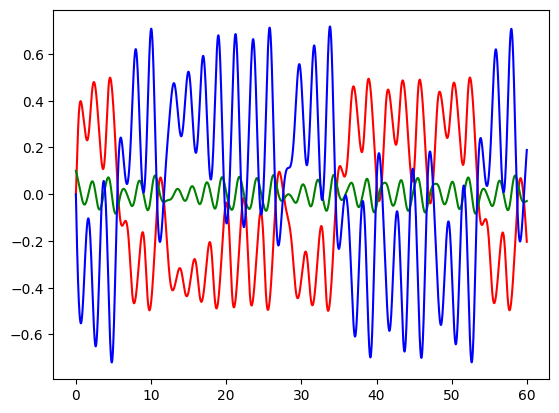

In [2]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 60

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [3]:
T_MAX = 750

@eqx.filter_jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 1/2))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                                max_steps=4096*2*2*2*2*2*2*2*2*2*2)

    x_train = sol_train.ys[::1]
    t_train = sol_train.ts[::1]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 1/2))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                              max_steps=4096*2*2*2*2*2*2*2*2*2*2*2)

    x_val = sol_val.ys[::1]
    t_val = sol_val.ts[::1]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [4]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


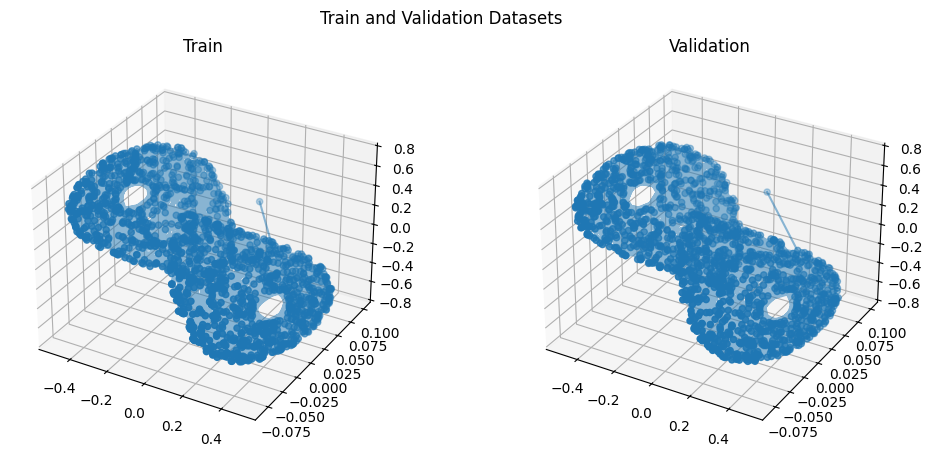

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].plot(sol_train.ys[:, 0],sol_train.ys[:, 1],sol_train.ys[:, 2],alpha=0.5)
axes[0].scatter(x_train[:, 0],x_train[:, 1],x_train[:, 2],)

axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5)
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2],)

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

In [6]:
x_train.shape

(1500, 3)

# Model
We use the UDE PEM x

In [7]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [8]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [9]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def call_pem(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)
    
    def call_normal(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)

    def __call__(self, t, state, args):
        obs_fun = args

        return jax.lax.cond(
                t > obs_fun.t_obs[-1],
                lambda _: self.call_normal(t, state, args),
                lambda _: self.call_pem(t, state, args),
                operand=None,
            )

# Training

In [73]:
@eqx.filter_jit
def solve_ude_long_horizon(model, y0, ts, obs_fun):
    t0s = ts[:-1]
    t1s = ts[1:]

    def scan_body(carry_y, times):
        t_start, t_end = times 
        sol = dfx.diffeqsolve(
            dfx.ODETerm(model),
            solver = dfx.Tsit5(),
            t0 = t_start, 
            t1 = t_end,
            dt0 = 0.1,
            y0 = carry_y,
            args=obs_fun,
            saveat = dfx.SaveAt(t1 = True)
        )

        y_final = sol.ys[-1]
        return y_final, y_final
    
    final_y, all_ys = jax.lax.scan(scan_body, y0, (t0s, t1s))
    
    return jnp.concatenate([y0[jnp.newaxis, ...], all_ys], axis=0)

In [ ]:
@eqx.filter_jit
def solve_ude_long_horizon(model, y0, ts, obs_fun):
    t0s = ts[:-1]
    t1s = ts[1:]

    def scan_body(carry_y, times):
        t_start, t_end = times 
        sol = dfx.diffeqsolve(
            dfx.ODETerm(model),
            solver = dfx.Tsit5(),
            t0 = t_start, 
            t1 = t_end,
            dt0 = 0.1,
            y0 = carry_y,
            args=obs_fun,
            saveat = dfx.SaveAt(t1 = True)
        )

        y_final = sol.ys[-1]
        return y_final, y_final
    
    final_y, all_ys = jax.lax.scan(scan_body, y0, (t0s, t1s))
    
    return jnp.concatenate([y0[jnp.newaxis, ...], all_ys], axis=0)


@eqx.filter_value_and_grad
def loss_fn_pem(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_ude_long_horizon(model, x0, ts, obs_fun)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step_pem(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn_pem(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [75]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	1.3002e-02	1.2591e-02
1	1.3102e-02	---
2	1.3503e-02	---
3	1.2914e-02	---
4	1.2934e-02	---
5	1.3067e-02	---
6	1.2786e-02	---
7	1.2652e-02	---
8	1.2735e-02	---
9	1.2681e-02	---
10	1.2503e-02	---
11	1.2436e-02	---
12	1.2468e-02	---
13	1.2373e-02	---
14	1.2230e-02	---
15	1.2193e-02	---
16	1.2177e-02	---
17	1.2071e-02	---
18	1.1980e-02	---
19	1.1946e-02	---
20	1.1876e-02	---
21	1.1784e-02	---
22	1.1737e-02	---
23	1.1674e-02	---
24	1.1574e-02	---
25	1.1504e-02	---
26	1.1427e-02	---
27	1.1317e-02	---
28	1.1223e-02	---
29	1.1113e-02	---
30	1.0985e-02	---
31	1.0864e-02	---
32	1.0711e-02	---
33	1.0547e-02	---
34	1.0373e-02	---
35	1.0164e-02	---
36	9.9424e-03	---
37	9.6738e-03	---
38	9.3783e-03	---
39	9.0339e-03	---
40	8.5805e-03	---
41	8.0398e-03	---
42	7.4258e-03	---
43	6.7240e-03	---
44	6.1352e-03	---
45	5.9463e-03	---
46	5.1464e-03	---
47	4.3734e-03	---
48	4.7471e-03	---
49	4.6315e-03	---
50	3.3341e-03	---
51	5.3000e-03	---
52	4.2615e-03	---
53	4.5416e-03	---
54	2.7123e-03	---
55	4.1598e-03

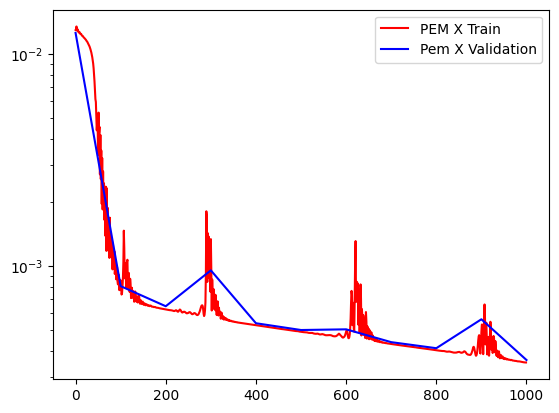

In [76]:
plt.semilogy(range(0, len(train_losses_pem)), train_losses_pem, color='red', label="PEM X Train")
plt.semilogy(100*jnp.array(range(len(val_losses_pem))), val_losses_pem, color='blue', label="Pem X Validation")

plt.legend()
plt.show()

In [82]:
eqx.tree_serialise_leaves("./models_weights/31_5_ude_jax_big_dataset_dthalf.eqx", ude_pem)

In [10]:
# Load model if needed
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit = eqx.filter_jit(linear_interp)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_5_ude_jax_big_dataset_dthalf.eqx", ude_pem)

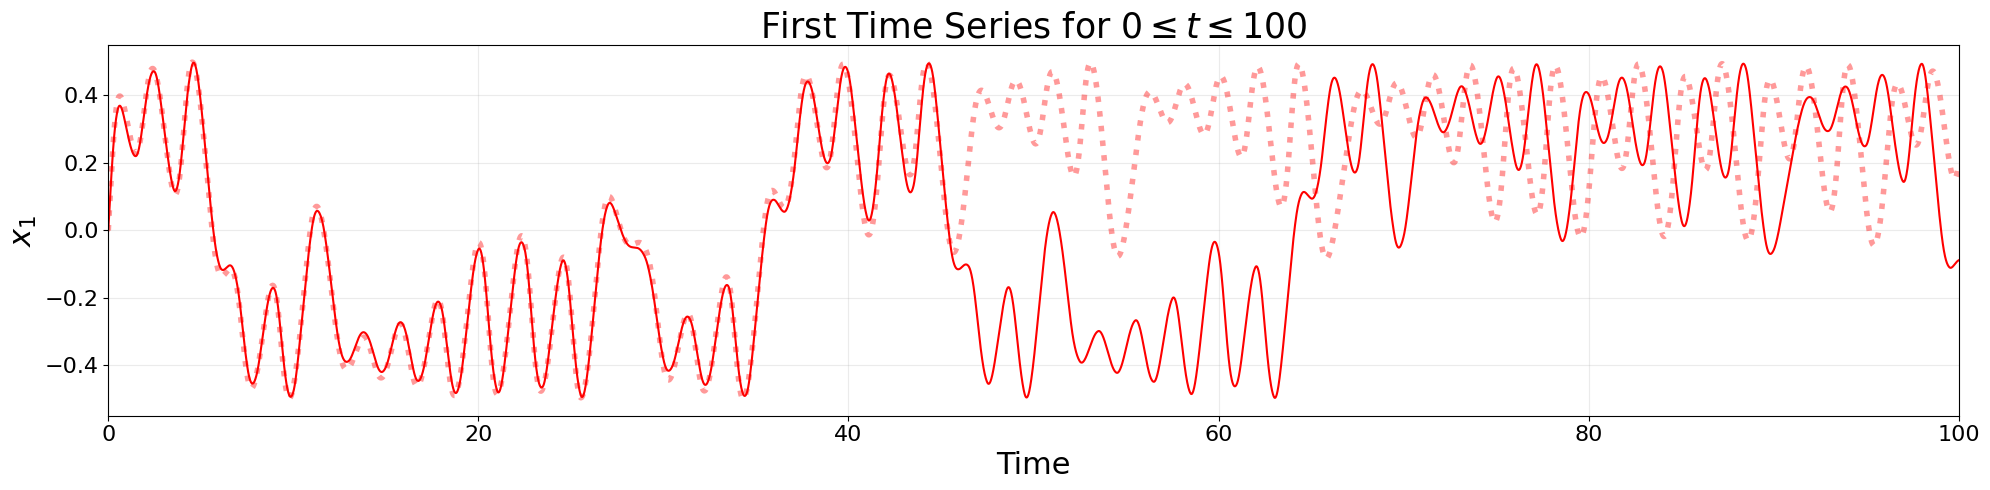

In [15]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 100

solver = dfx.Tsit5()
y0 = x_train[0]

t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# Solve the true model
sol = dfx.diffeqsolve(
    term,
    solver,
    t0=0,
    t1=T_MAX,
    dt0=0.00001,
    y0=y0,
    args=(ALPHA, BETA, GAMMA, A, C),
    saveat=saveat,
    stepsize_controller=stepper,
    max_steps=4096 * 2**5,
)
traj_true = sol.ys

# Solve the UDE model
traj_final = dfx.diffeqsolve(
    term_ude,
    solver,
    t0=0,
    t1=T_MAX,
    dt0=0.00001,
    y0=y0,
    args=linear_interp,
    saveat=saveat,
    stepsize_controller=stepper,
    max_steps=4096 * 2**7,
).ys

# Plot only the first time series
fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(
    t_eval,
    traj_final[:, 0],
    color=col_dict[0],
    label="UDE prediction",
)

ax.plot(
    t_eval,
    traj_true[:, 0],
    color=col_dict[0],
    linestyle=":",
    linewidth=4,
    alpha=0.4,
    label="True trajectory",
)

# Show the final training point only when it lies in the displayed interval
if t_train[-1] <= T_MAX:
    ax.axvline(
        t_train[-1],
        color="k",
        linestyle="--",
        label="Last training-set point",
    )

ax.set_xlim(0, T_MAX)
ax.set_xlabel("Time", fontsize=22)
ax.set_ylabel(r"$x_1$", fontsize=22)
ax.set_title(r"First Time Series for $0 \leq t \leq 100$", fontsize=25)
ax.tick_params(axis="both", labelsize=16)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

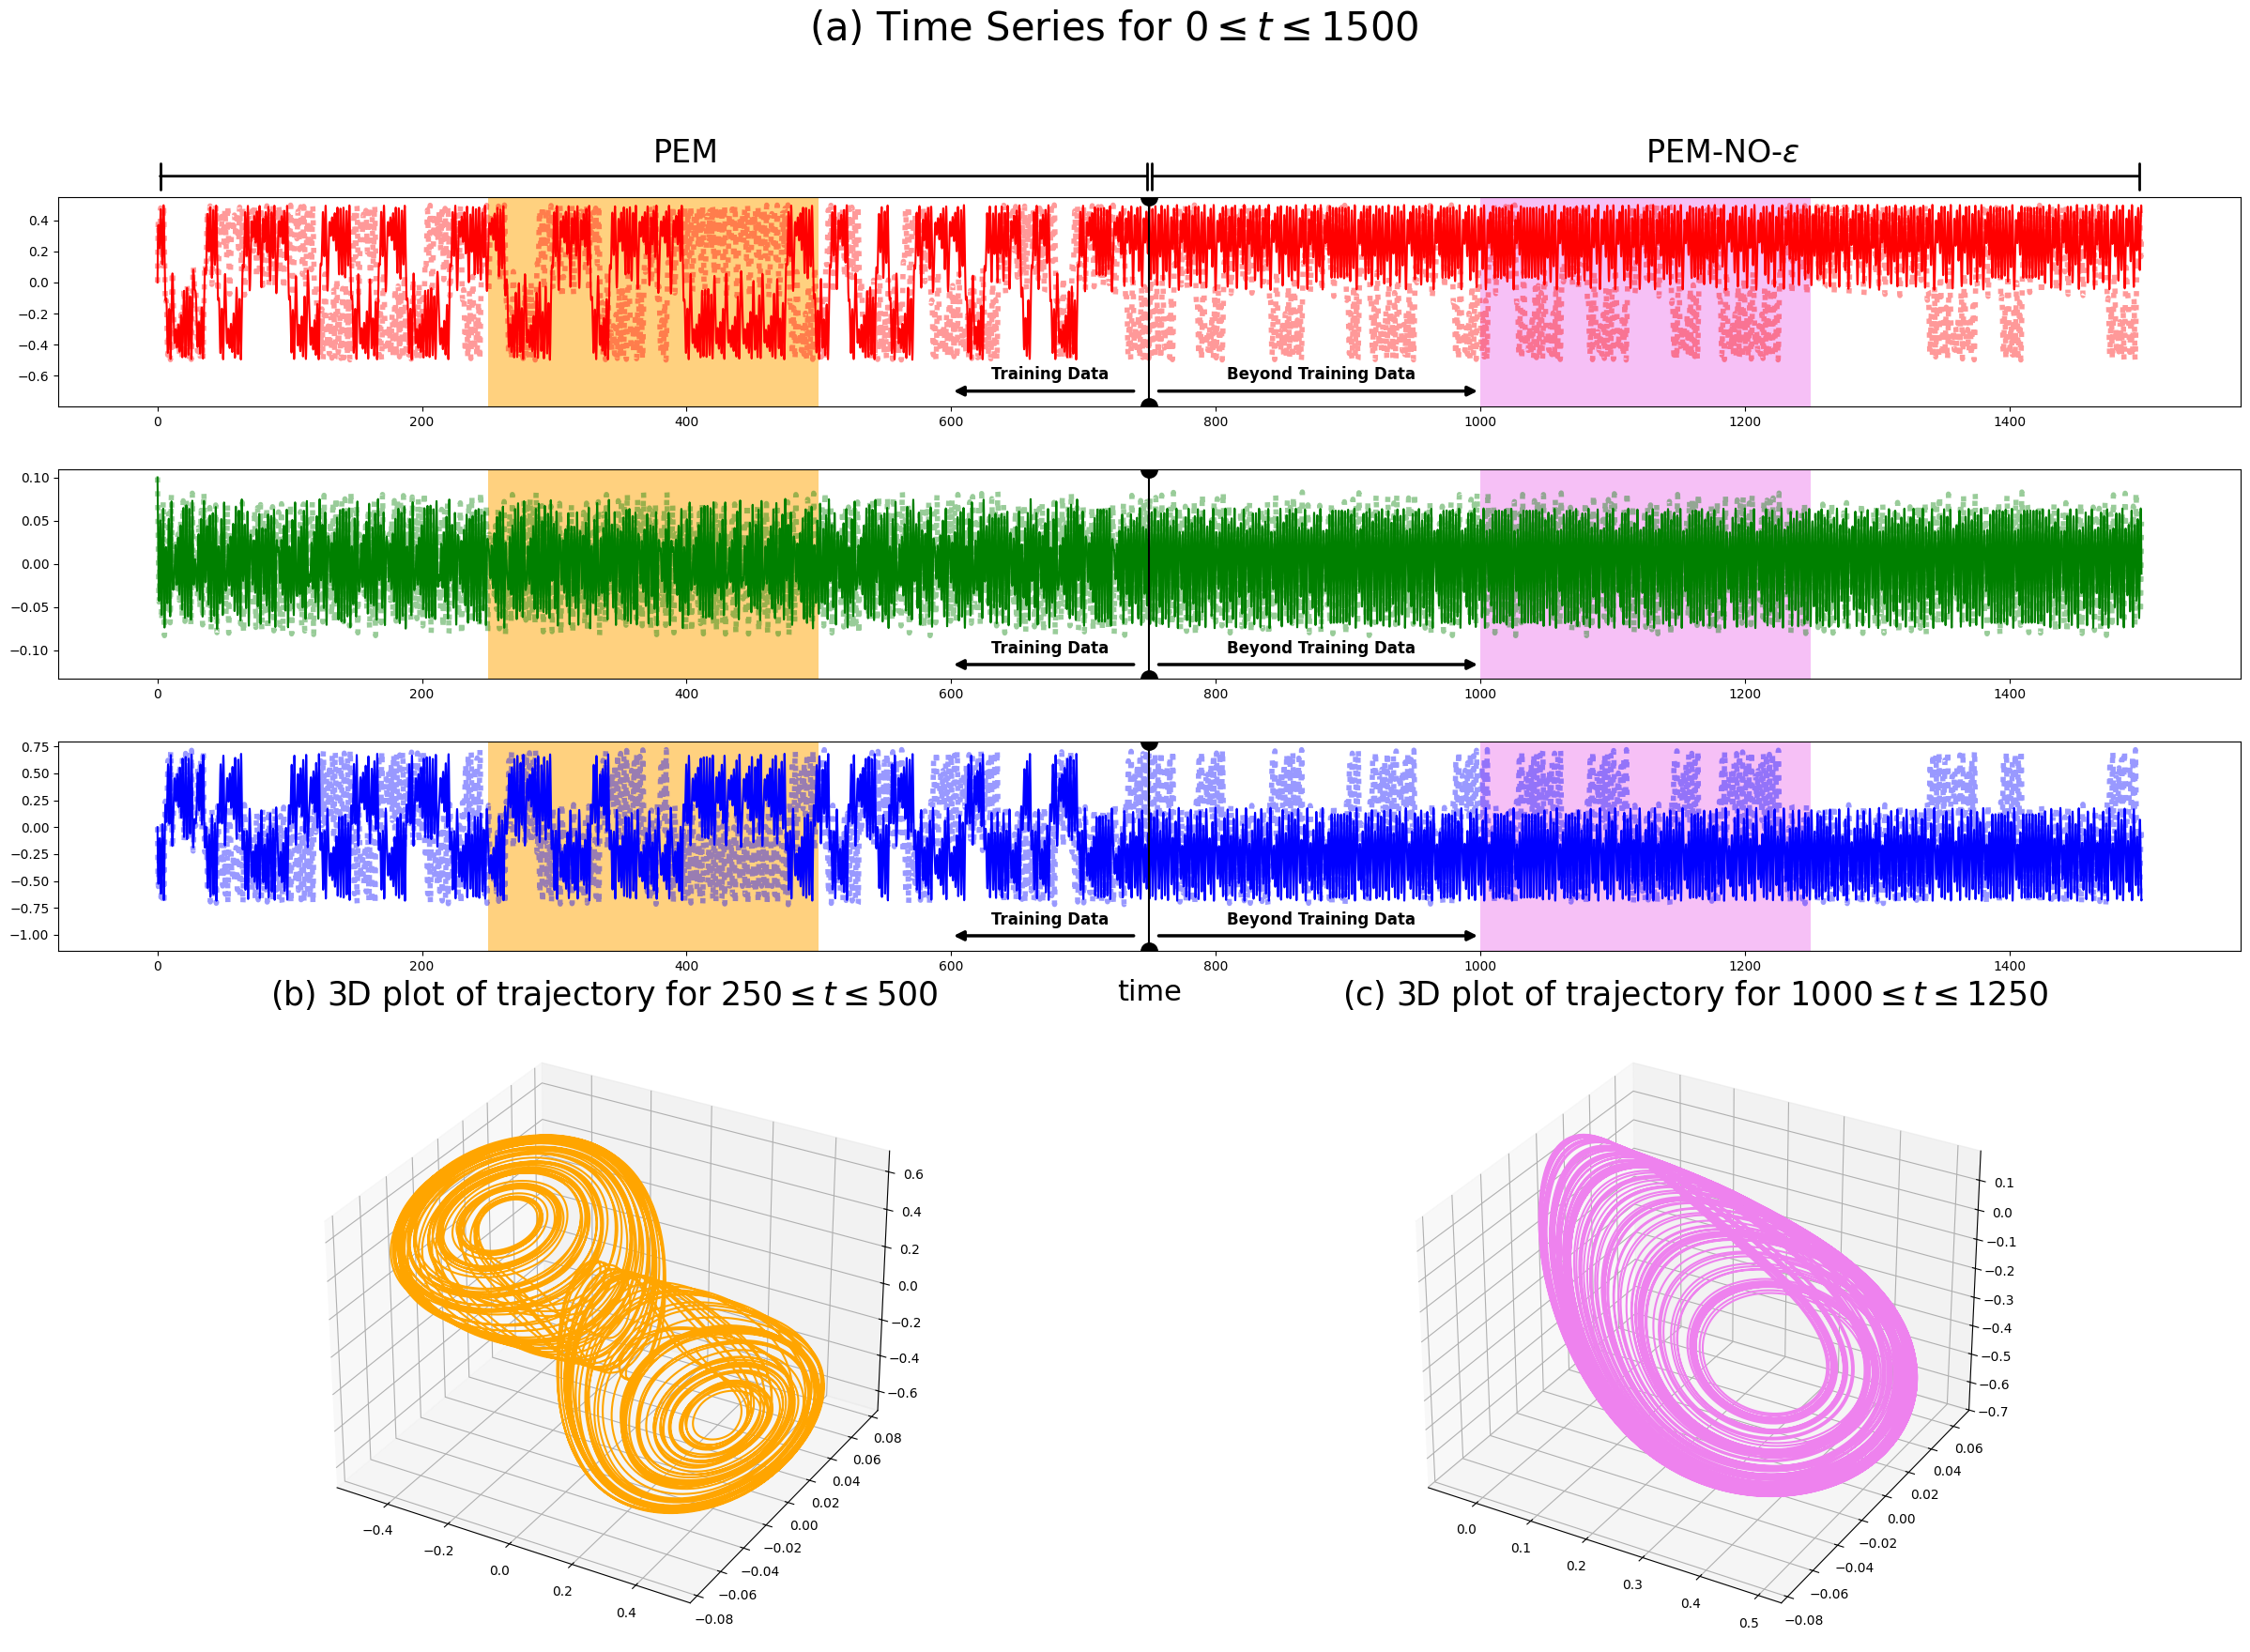

In [11]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 1500

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set

mosaic = [
    [ 0, 0],
    [ 1, 1,],
    [ 2, 2,],
    [ '3dplot_1', '3dplot_2']
]

fig, axes = plt.subplot_mosaic(mosaic=mosaic, figsize=(30, 20), 
                               per_subplot_kw={'3dplot_1': {'projection': '3d'}, 
                                               '3dplot_2': {'projection': '3d'}},
                                               gridspec_kw={'height_ratios': [1, 1, 1, 3], 'wspace':0}
)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.00001, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper, 
                      max_steps=4096*2*2*2*2*2)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.00001, y0=y0, args=linear_interp, saveat=saveat, stepsize_controller=stepper, 
                             max_steps=4096*2*2*2*2*2*2*2,
                             ).ys

plt.sca(axes[0])
plt.suptitle("(a) Time Series for $0 \\leq t \\leq 1500$", size=30)

for i in range(3):
    plt.sca(axes[i])
    axes[i].plot(t_eval, traj_final[:, i], color=col_dict[i],)
    axes[i].plot(t_eval, traj_true[:, i], color=col_dict[i], linestyle=':', linewidth=4, alpha=0.4)
    plt.axvline(t_train[-1], color="k", label="Last Training Set Point", marker=".", markersize=25)

    y_min = min(jnp.min(traj_true[:, i]), jnp.min(traj_final[:, i]))
    y_max = max(jnp.max(traj_true[:, i]), jnp.max(traj_final[:, i]))
    plt.ylim(y_min * 1.6, None)

    if i==0:
        trans = axes[i].get_xaxis_transform()
        plt.annotate(
            "",
            xy=(0, 1.1),
            xytext=(750, 1.1),
            xycoords=trans,
            textcoords=trans,
            arrowprops=dict(
                arrowstyle="|-|",
                lw=2,
                color="k"
            ),
            annotation_clip=False
        )

        trans = axes[i].get_xaxis_transform()
        plt.annotate(
            "",
            xy=(750, 1.1),
            xytext=(1500, 1.1),
            xycoords=trans,
            textcoords=trans,
            arrowprops=dict(
                arrowstyle="|-|",
                lw=2,
                color="k"
            ),
            annotation_clip=False
        )

        plt.text(0.5*(0 + 750), y_max*1.55, "PEM", size=24)
        plt.text(0.5*(750 + 1500), y_max*1.55, r"PEM-NO-$\varepsilon$", size=24)

    plt.annotate('', xy=(1000, y_min+y_min*0.4), xytext=(755, y_min+y_min*.4), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(1000+760), y_min+y_min*0.3, r"Beyond Training Data", ha="center", va="bottom", weight="bold",size=12)
# 
    plt.annotate('', xy=(740, y_min+y_min*0.4), xytext=(600, y_min+y_min*.4), arrowprops=dict(arrowstyle="<|-", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(740+600+10), y_min+y_min*0.3, r"Training Data", ha="center", va="bottom", weight="bold", size=12 )

    plt.axvspan(250, 500, lw=0, color='orange', alpha=0.5)
    plt.axvspan(1000, 1250, lw=0, color='violet', alpha=0.5)

plt.xlabel("time", size=22)

plt.sca(axes['3dplot_1'])
plt.title("(b) 3D plot of trajectory for $250 \\leq t \\leq 500$", size=25)

plt.sca(axes['3dplot_2'])
plt.title("(c) 3D plot of trajectory for $1000 \\leq t \\leq 1250$", size=25)

axes['3dplot_1'].plot(traj_final[250*100:500*100, 0],traj_final[250*100:500*100, 1],traj_final[250*100:500*100, 2],alpha=1, color='orange')
axes['3dplot_2'].plot(traj_final[1000*100:1250*100, 0],traj_final[1000*100:1250*100, 1],traj_final[1000*100:1250*100, 2], alpha=1, color='violet')

plt.show()


## Model extrapolation 

### 1. Plot learned network and compare to the real polynomial

In [54]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)

linear_interp_val = LinearInterpolator(t_val, x_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_5_ude_jax_big_dataset_dthalf.eqx", ude_pem)

In [55]:
# plot learned network
y_hats = []
ys = []
for x in (x_space:=jnp.arange(-1, 1, 0.01)):
    y_hat = ude_pem.net(x)
    y_hats.append(y_hat)
    ys.append(A*x**3 + C*x)


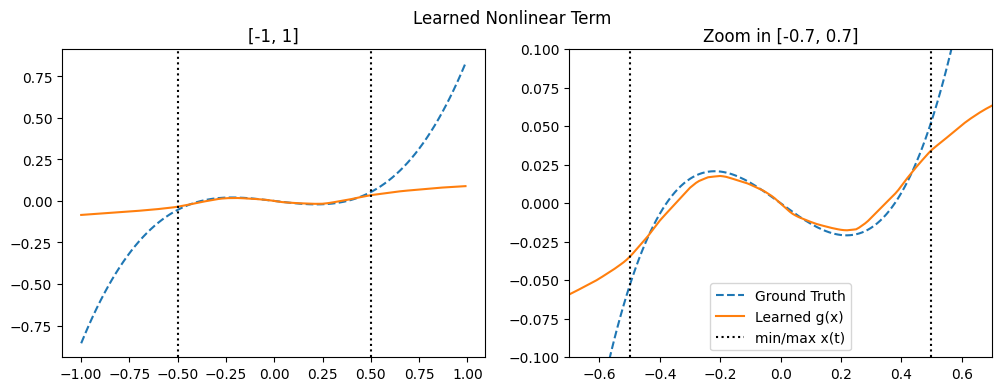

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(axes[0])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.title("[-1, 1]")

plt.sca(axes[1])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.xlim(-0.7, 0.7)
plt.ylim(-0.1, 0.1)
plt.title("Zoom in [-0.7, 0.7]")

plt.legend()
plt.suptitle("Learned Nonlinear Term")

plt.show()

In [57]:
import jax.numpy as jnp
import numpy as np

data = np.genfromtxt(
    "./losses/31_5_losses_750_final.txt",
    delimiter="\t",     
    missing_values="---", # set --- as NaN
    filling_values=np.nan
)

data_jax = jnp.array(data)
clean_rows = data_jax[~jnp.isnan(data_jax).any(axis=1)]

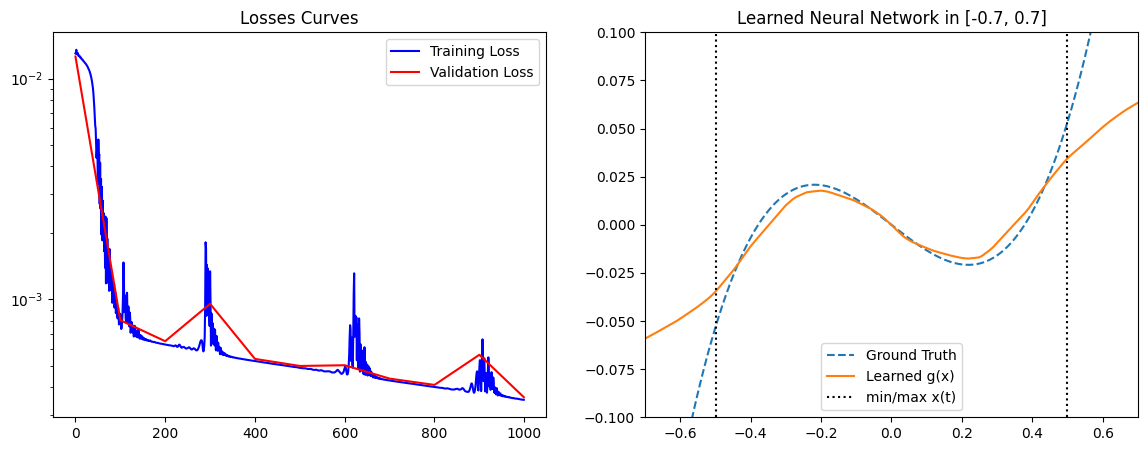

In [58]:
# Thesis purposes: plot, at left, the losses curve and on the right the learned trajectories

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
plt.semilogy(data_jax[:, 0], data_jax[:, 1], label="Training Loss", color='blue')
plt.semilogy(clean_rows[:, 0], clean_rows[:, 2], label="Validation Loss", color="red")
plt.title("Losses Curves")
plt.legend()

plt.sca(axes[1])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.xlim(-0.7, 0.7)
plt.ylim(-0.1, 0.1)
plt.title("Learned Neural Network in [-0.7, 0.7]")
plt.legend()

plt.show()
